In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC, SVR


In [12]:
df = pd.read_csv("Cust_Encoded_data.csv")

df

,Unnamed: 0,Gender,Customer Type,Type of Travel,Class,satisfaction,Age,Flight Distance,Inflight entertainment,Baggage handling,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
0,0,1,1,1,1,0,13,460,5,4,5,25,18.0
1,1,1,2,2,2,0,25,235,1,3,1,1,6.0
2,2,2,1,2,2,1,26,1142,5,4,5,0,0.0
3,3,2,1,2,2,0,25,562,2,3,2,11,9.0
4,4,1,1,2,2,1,61,214,3,4,3,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
103417,103899,2,2,2,3,0,23,192,2,4,2,3,0.0
103418,103900,1,1,2,2,1,49,2347,5,5,4,0,0.0
103419,103901,1,2,2,2,0,30,1995,4,4,4,7,14.0
103420,103902,2,2,2,3,0,22,1000,1,1,1,0,0.0


In [13]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 103422 entries, 0 to 103421
Data columns (total 13 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Unnamed: 0                  103422 non-null  int64  
 1   Gender                      103422 non-null  int64  
 2   Customer Type               103422 non-null  int64  
 3   Type of Travel              103422 non-null  int64  
 4   Class                       103422 non-null  int64  
 5   satisfaction                103422 non-null  int64  
 6   Age                         103422 non-null  int64  
 7   Flight Distance             103422 non-null  int64  
 8   Inflight entertainment      103422 non-null  int64  
 9   Baggage handling            103422 non-null  int64  
 10  Cleanliness                 103422 non-null  int64  
 11  Departure Delay in Minutes  103422 non-null  int64  
 12  Arrival Delay in Minutes    103422 non-null  float64
dtypes: float64(1), int64(12)


In [14]:
df['satisfaction'].value_counts()

satisfaction
0    58636
1    44786
Name: count, dtype: int64

In [15]:
x=df.drop('satisfaction', axis=1)
y =df[['satisfaction']]


In [16]:
y

,satisfaction
0,0
1,0
2,1
3,0
4,1
...,...
103417,0
103418,1
103419,0
103420,0


In [17]:
x

,Unnamed: 0,Gender,Customer Type,Type of Travel,Class,Age,Flight Distance,Inflight entertainment,Baggage handling,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
0,0,1,1,1,1,13,460,5,4,5,25,18.0
1,1,1,2,2,2,25,235,1,3,1,1,6.0
2,2,2,1,2,2,26,1142,5,4,5,0,0.0
3,3,2,1,2,2,25,562,2,3,2,11,9.0
4,4,1,1,2,2,61,214,3,4,3,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
103417,103899,2,2,2,3,23,192,2,4,2,3,0.0
103418,103900,1,1,2,2,49,2347,5,5,4,0,0.0
103419,103901,1,2,2,2,30,1995,4,4,4,7,14.0
103420,103902,2,2,2,3,22,1000,1,1,1,0,0.0


In [18]:
from sklearn.model_selection import train_test_split

# Assuming you want to split y into train and test sets
x_train , x_test , y_train, y_test = train_test_split(x , y, test_size=0.2, random_state=42)

y_test

,satisfaction
40650,1
28487,1
4906,0
70882,1
66907,1
...,...
78075,1
47623,1
69666,0
6445,0


In [19]:
x_train ,x_test,y_train,y_test = train_test_split(x , y, test_size=0.2, random_state=42)

In [20]:
from sklearn.tree import DecisionTreeClassifier


In [21]:
sv=DecisionTreeClassifier()
sv.get_params()


{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'best'}

In [22]:
sv.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [23]:
pred=sv.predict(x_test)
pred

array([1, 1, 0, ..., 0, 0, 0], shape=(20685,))

In [24]:
print("Traning score:", sv.score(x_train, y_train))
print("Testing score:", sv.score(x_test, y_test))


Traning score: 1.0
Testing score: 0.8136814116509548


In [13]:
sv =SVC()

In [ ]:
sv.fit(x_train, y_train)

e:\Data science\Python\liet_data\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
sv.score(x_test, y_test)


0.6517766497461929

In [ ]:
pred=sv.predict(x_test)
pred

array([1, 0, 0, ..., 0, 0, 0], shape=(20685,))

In [ ]:
pred[0:20]

array([1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [ ]:
y_test[0:10]

,satisfaction
40650,1
28487,1
4906,0
70882,1
66907,1
25894,0
80825,0
100576,0
54859,1
2547,1


In [ ]:
df['satisfaction'].value_counts()

satisfaction
0    58636
1    44786
Name: count, dtype: int64

In [ ]:
cust_satisfaction_count=df['satisfaction'].value_counts()

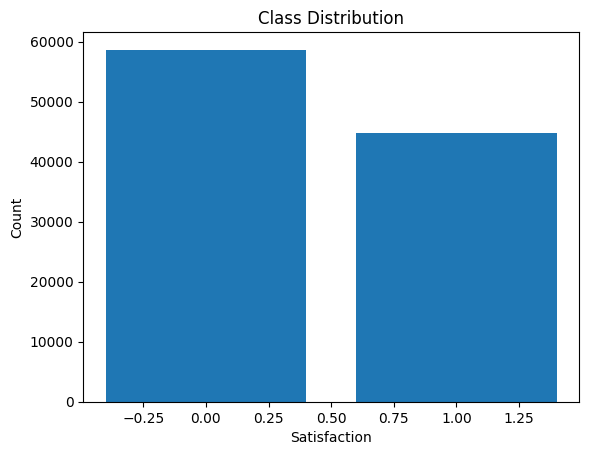

In [ ]:
plt.bar(cust_satisfaction_count.index, cust_satisfaction_count.values)
plt.xlabel('Satisfaction')
plt.ylabel('Count')
plt.title('Class Distribution')
plt.show()

In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y)
sm=SMOTE(random_state=42)
x_train_res, y_train_res= sm.fit_resample(x_train, y_train)


In [ ]:
satisfaction_bar = y_train_res['satisfaction'].value_counts()


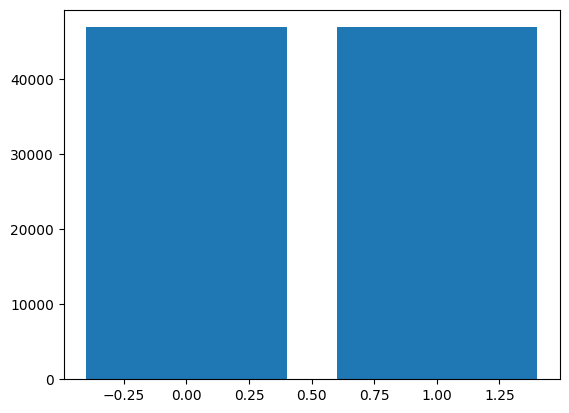

In [ ]:
plt.bar(satisfaction_bar.index, satisfaction_bar.values)
plt.show()

In [ ]:
sv.fit(x_train_res, y_train_res)

e:\Data science\Python\liet_data\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [ ]:
pred =sv.predict(x_test)

In [ ]:
pred

array([0, 0, 1, ..., 1, 0, 0], shape=(20685,))

In [ ]:
pred[0:20]

array([0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0])

In [ ]:
y_test[0:20]

,satisfaction
88534,0
100761,0
99483,0
29888,0
76353,1
26225,1
17057,0
60241,1
66910,1
66521,1


In [ ]:
sv.score(x_test, y_test)

0.6611070824268794

In [ ]:
sv.score(x_train_res, y_train_res)


0.6376950626758762

In [1]:
from sklearn.tree import DecisionTreeClassifier


In [2]:
sv=DecisionTreeClassifier()
sv.get_params()


{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'best'}

In [5]:
sv.fit(x_train_res, y_train_res)

NameError: name 'x_train_res' is not defined